In [1]:
import pandas as pd
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


In [2]:
dataframe = pd.read_csv('reviews.csv')
dataframe

,reviewText
0,This is a one of the best apps acording to a b...
1,This is a pretty good version of the game for ...
2,this is a really cool game. there are a bunch ...
3,"This is a silly game and can be frustrating, b..."
4,This is a terrific game on any pad. Hrs of fun...
...,...
19995,this app is fricken stupid.it froze on the kin...
19996,Please add me!!!!! I need neighbors! Ginger101...
19997,love it! this game. is awesome. wish it had m...
19998,I love love love this app on my side of fashio...


In [3]:

def preprocess_text(text):
    #tokenize the text 
    tokens = word_tokenize(text.lower())
    #remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]
    #lemmatize the tokens
    lemmatizer =  WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    #Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

dataframe['reviewText'] = dataframe['reviewText'].apply(preprocess_text)
dataframe 

,reviewText
0,one best apps acording bunch people agree bomb...
1,pretty good version game free . lot different ...
2,really cool game . bunch level find golden egg...
3,"silly game frustrating , lot fun definitely re..."
4,terrific game pad . hr fun . grandkids love . ...
...,...
19995,app fricken stupid.it froze kindle wont allow ...
19996,please add ! ! ! ! ! need neighbor ! ginger101...
19997,love ! game . awesome . wish free stuff house ...
19998,love love love app side fashion story fight wo...


In [4]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment

dataframe['sentiment'] = dataframe['reviewText'].apply(get_sentiment)
dataframe

,reviewText,sentiment
0,one best apps acording bunch people agree bomb...,1
1,pretty good version game free . lot different ...,1
2,really cool game . bunch level find golden egg...,1
3,"silly game frustrating , lot fun definitely re...",1
4,terrific game pad . hr fun . grandkids love . ...,1
...,...,...
19995,app fricken stupid.it froze kindle wont allow ...,0
19996,please add ! ! ! ! ! need neighbor ! ginger101...,1
19997,love ! game . awesome . wish free stuff house ...,1
19998,love love love app side fashion story fight wo...,1


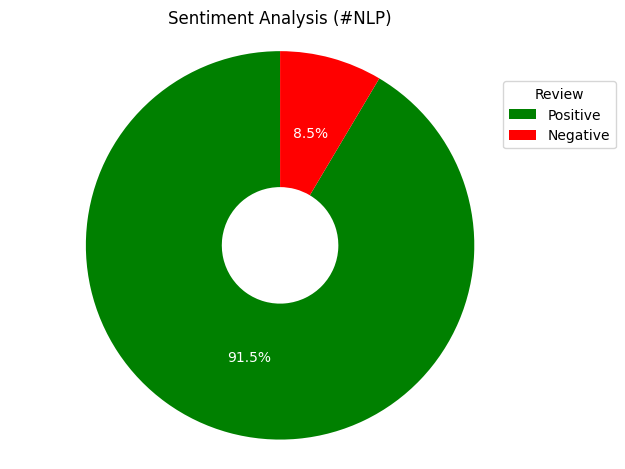

In [7]:
import matplotlib.pyplot as plt

sentiment_counts = dataframe['sentiment'].value_counts()

labels = sentiment_counts.index
sizes = sentiment_counts.values

fig, ax = plt.subplots()

colors = ['green', 'red']

wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
                                  wedgeprops=dict(width=0.7), textprops=dict(color="w"), colors = colors)

centre_circle = plt.Circle((0,0),0.25,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

legend_labels = ['Positive', 'Negative']
ax.legend(wedges, legend_labels, title='Review', loc='upper left', bbox_to_anchor=(0.9, 0.9))

ax.axis('equal')

plt.title('Sentiment Analysis (#NLP)')
plt.tight_layout()
plt.savefig('C:/Users/USER/Desktop/Analysis/reviews.jpg')
plt.show()
